In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1) Загрузка данных
df = pd.read_csv("diabetes.csv")

# 2) Признаки без Outcome
feature_cols = [c for c in df.columns if c != "Outcome"]

# 3) События: признак <= медианы признака
events = {}
medians = {}
for col in feature_cols:
    med = df[col].median()
    medians[col] = med
    events[col] = df[col] <= med

# 4) Матрица K_ij = P(A_i | B_j) / P(A_i)
n = len(df)
k_matrix = pd.DataFrame(index=feature_cols, columns=feature_cols, dtype=float)

for i_col in feature_cols:
    a = events[i_col]
    n_a = int(a.sum())
    p_a = n_a / n if n else 0.0

    for j_col in feature_cols:
        b = events[j_col]
        n_b = int(b.sum())
        n_ab = int((a & b).sum())

        p_a_given_b = (n_ab / n_b) if n_b else 0.0
        k_ij = (p_a_given_b / p_a) if p_a else 0.0
        k_matrix.loc[i_col, j_col] = k_ij

print("Medians:")
display(pd.Series(medians, name="median"))

print("Colligation matrix K:")
display(k_matrix.round(4))

# 5) Сохранение в CSV
k_matrix.to_csv("colligation_matrix.csv")
print("Saved: colligation_matrix.csv")

Medians:


Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      30.5000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Name: median, dtype: float64

Colligation matrix K:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.8113,1.1072,1.1456,0.9760,0.8066,1.0417,0.9764,1.5094
Glucose,1.1072,1.9642,1.1626,1.0781,1.0639,1.1704,1.0588,1.2003
BloodPressure,1.1456,1.1626,1.8329,1.0795,0.9547,1.1729,0.9976,1.2312
SkinThickness,0.9760,1.0781,1.0795,1.9248,1.3734,1.3962,1.1078,1.0013
Insulin,0.8066,1.0639,0.9547,1.3734,2.0000,1.1088,1.1823,0.8232
BMI,1.0417,1.1704,1.1729,1.3962,1.1088,1.9896,1.0725,1.0752
DiabetesPedigreeFunction,0.9764,1.0588,0.9976,1.1078,1.1823,1.0725,2.0000,1.0253
Age,1.5094,1.2003,1.2312,1.0013,0.8232,1.0752,1.0253,1.9394


Saved: colligation_matrix.csv


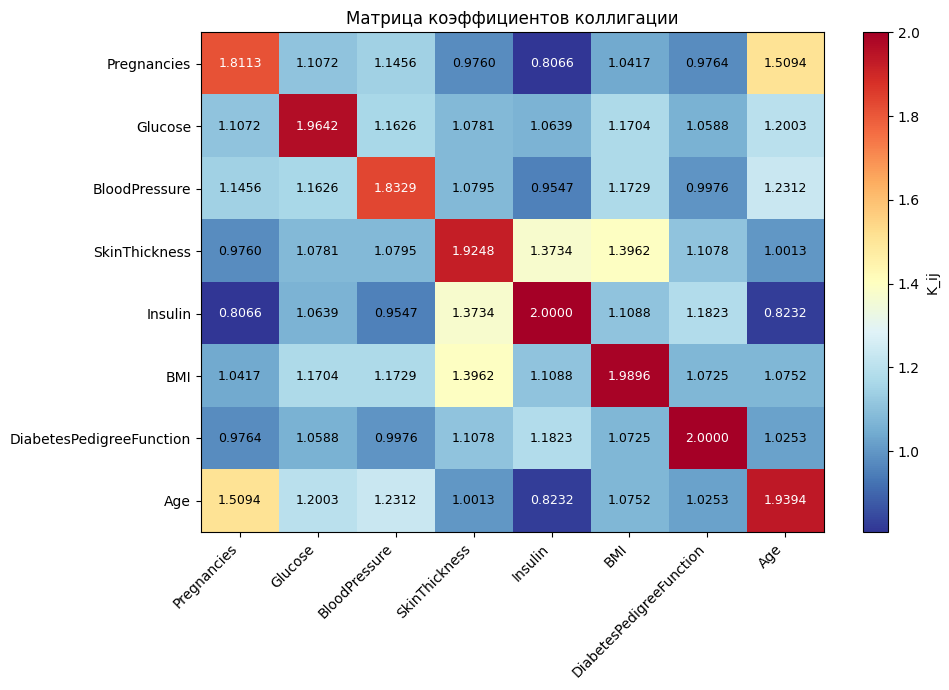

In [ ]:
# 6) Heatmap матрицы коэффициентов
fig, ax = plt.subplots(figsize=(10, 7))

M = k_matrix.values.astype(float)
im = ax.imshow(M, cmap="RdYlBu_r", aspect="auto")

ax.set_xticks(np.arange(len(feature_cols)))
ax.set_yticks(np.arange(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticklabels(feature_cols)

# Подписи значений в ячейках
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        val = M[i, j]
        color = "white" if (val < 0.95 or val > 1.75) else "black"
        ax.text(j, i, f"{val:.4f}", ha="center", va="center", color=color, fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("K_ij")

ax.set_title("Матрица коэффициентов коллигации")
plt.tight_layout()
plt.show()